In [8]:
import numpy as np
import pandas as pd
from numba import njit
from datetime import timedelta
import talib
import vectorbt as vbt
from vectorbt.indicators.factory import IndicatorFactory

from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

#My other files
from Data_Handling import *
from Alpaca_Credentials import ALPACA_API_KEY, ALPACA_SECRET_KEY
client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)


import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from itertools import product
import optuna


In [ ]:
# Configuration
symbol = "SPY"
start_date = "2018-01-01" # 2002 to 2023
end_date = "2025-05-20"
optimization_window_days = 3
execution_window_days = 1
timeframe_unit = "Minute"
multiplier = 1


entry_thresholds = np.arange(5,40,5)
exit_thresholds = np.arange (60,95,5)
rsi_periods = np.arange (7, 98, 7)

In [5]:
# 1. Load Data
data = get_data_auto(symbol, start=start_date, end=end_date, timeframe_unit=timeframe_unit, multiplier=multiplier)


In [6]:
#2. Define Strategy
@njit
def logic(rsi_vals, entry_threshold, exit_threshold):
    signals = np.where(rsi_vals<entry_threshold,1,0)
    return np.where(rsi_vals>exit_threshold,-1,signals)

def run_RSI_strat1(close, entry_threshold, exit_threshold, rsi_period):
    rsi_vals = vbt.IndicatorFactory.from_talib("RSI").run(close, rsi_period).real.to_numpy()
    return logic(rsi_vals, entry_threshold, exit_threshold)

RSI_strat1 = IndicatorFactory(
    class_name="RSI1",
    short_name="rsi1",
    input_names=["close"],
    param_names=["entry_threshold","exit_threshold","rsi_period"],
    output_names=["signals"] 
    ).from_apply_func(
        run_RSI_strat1
        )



In [9]:
#3. Walk-forward Loop
dates = data.index.normalize().unique()
results=[]
all_trades=[]

for i in range(optimization_window_days, len(dates)- execution_window_days):
    training_start = dates[i - optimization_window_days]
    training_end = dates[i] - timedelta(seconds=1)
    test_start = dates[i]
    test_end = dates[i+ execution_window_days]

    training_data = data.loc[training_start:training_end]
    test_data = data.loc[test_start:test_end]

    #3.1 Optimize on traning dates over parameters
    call_signals = RSI_strat1.run(
        close = training_data["Close"],
        entry_threshold = entry_thresholds,
        exit_threshold = exit_thresholds,
        rsi_period = rsi_periods,
        param_product = True
        )

    pf_test = vbt.Portfolio.from_signals(
        close = training_data["Close"],
        entries = (call_signals.signals == 1.0),
        exits = (call_signals.signals == -1.0),
        size = 1,
        sl_stop = 0.01,
        tp_stop = 0.02 ,
        freq = "m"
        )
    
    best_params, best_value, best_pf = Overfitting_reduction(pf_test, objective_function=None, smoothing_size=3, filter_threshold=0.0)
    #print(best_params)
    #3.2 Run with optimised parameters
    optimum_signals = RSI_strat1.run(
        close = test_data["Close"],
        entry_threshold = best_params["rsi1_entry_threshold"],
        exit_threshold = best_params["rsi1_exit_threshold"],
        rsi_period = best_params["rsi1_rsi_period"]
        )
    pf_results = vbt.Portfolio.from_signals(
        close=test_data["Close"],
        entries = (optimum_signals.signals == 1.0),
        exits = (optimum_signals.signals == -1.0),
        size = 1,
        sl_stop = 0.01,
        tp_stop = 0.02,
        freq = "m"
        )
    all_trades.append(pf_results)
    results.append({
        "date": test_start,
        "params": best_params,
        "return": pf_results.total_return()
        })
    #print(best_value)
    #print(pf_results.total_return())



In [14]:
#df = fetch_alpaca_vbt_data("AAPL", "2023-01-01", "2024-01-01", timeframe_unit="Hour", multiplier=1)

# Access OHLCV as NumPy
close = data.get("Close")  # pandas Series
close_np = close.values  # NumPy

# Plot
close.vbt.plot()

FigureWidget({
    'data': [{'name': 'Close',
              'showlegend': True,
              'type': 'scatter',
              'uid': 'f0ef0d0c-2fd7-49c3-8312-34c975cdc3d1',
              'x': array([datetime.datetime(2018, 1, 2, 9, 0, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2018, 1, 2, 9, 1, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2018, 1, 2, 9, 2, tzinfo=TzInfo(UTC)), ...,
                          datetime.datetime(2025, 5, 19, 23, 56, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 58, tzinfo=TzInfo(UTC)),
                          datetime.datetime(2025, 5, 19, 23, 59, tzinfo=TzInfo(UTC))],
                         dtype=object),
              'y': array([266.99  , 266.99  , 266.97  , ..., 595.3799, 595.5   , 595.54  ])}],
    'layout': {'height': 350,
               'legend': {'orientation': 'h',
                          'traceorder': 'normal',
                          'x': 1,
                  

Final year total return: 298.20%


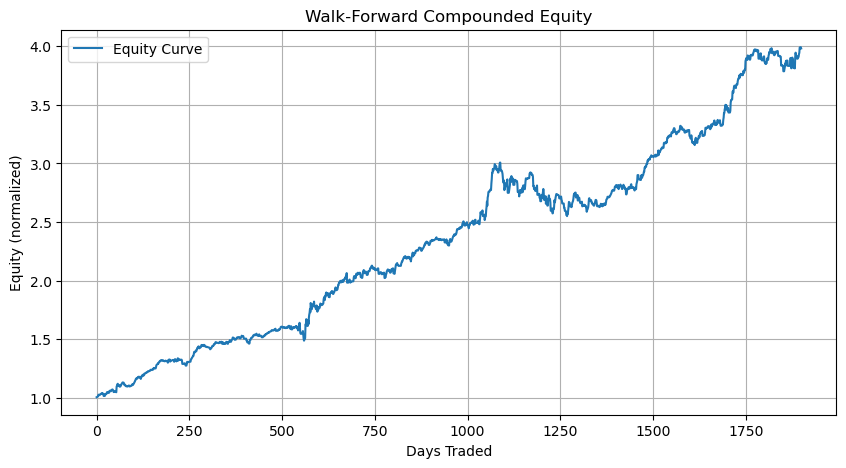

In [10]:
# Extract total return for each daily portfolio
daily_returns = [pf.total_return() for pf in all_trades]  # e.g., 0.012, -0.008, 0.005

# Convert to growth factors
factors = [1 + r for r in daily_returns]

# Cumulative product to simulate reinvestment
cumulative_growth = np.cumprod(factors)

# Final year return
final_return = cumulative_growth[-1] - 1

print(f"Final year total return: {final_return:.2%}")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(cumulative_growth, label="Equity Curve")
plt.title("Walk-Forward Compounded Equity")
plt.xlabel("Days Traded")
plt.ylabel("Equity (normalized)")
plt.grid(True)
plt.legend()
plt.show()



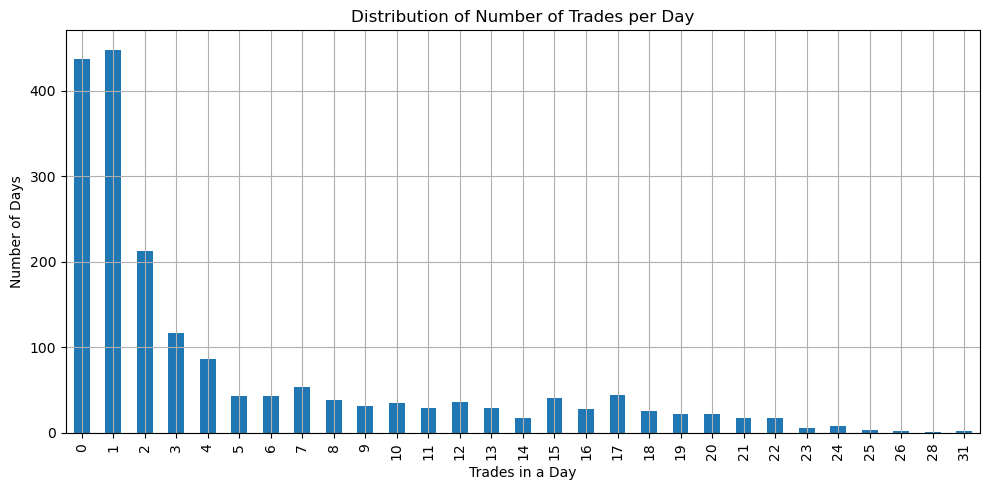

In [11]:
# Assuming `all_trades` is a list of vectorbt.Portfolio objects
# Each one represents a single day's walk-forward backtest result

# Step 1: Count trades for each portfolio
trade_counts = [pf.trades.count() for pf in all_trades]

# Step 2: Create Series
trade_counts_series = pd.Series(trade_counts, name="trade_count")

# Step 3: Build histogram (how many days had X trades)
trade_distribution = trade_counts_series.value_counts().sort_index()

# Step 4: Plot
plt.figure(figsize=(10, 5))
trade_distribution.plot(kind='bar')
plt.title("Distribution of Number of Trades per Day")
plt.xlabel("Trades in a Day")
plt.ylabel("Number of Days")
plt.grid(True)
plt.tight_layout()
plt.show()


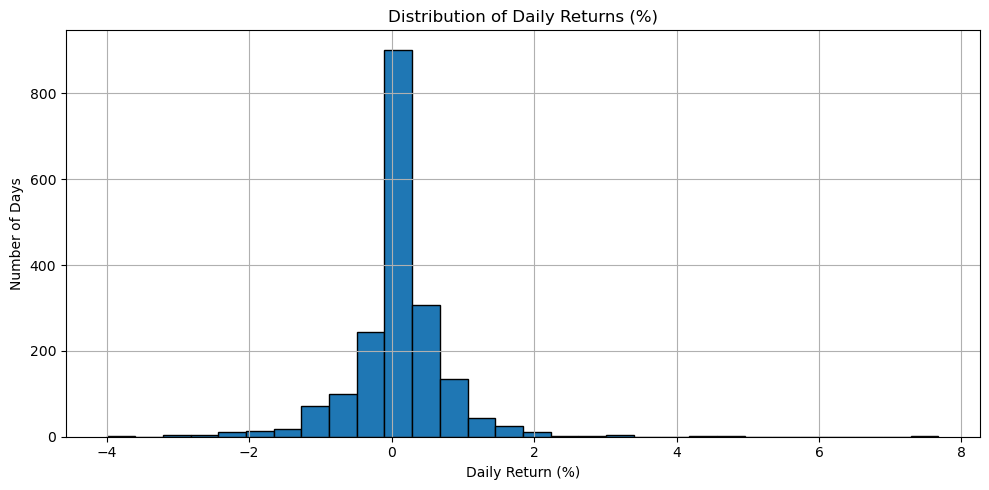

In [12]:
# Step 1: Get total returns from each daily portfolio
daily_returns = [pf.total_return() for pf in all_trades]

# Step 2: Convert to percentage
daily_returns_pct = pd.Series(daily_returns) * 100

# Step 3: Plot histogram
plt.figure(figsize=(10, 5))
daily_returns_pct.plot(kind='hist', bins=30, edgecolor='black')

plt.title("Distribution of Daily Returns (%)")
plt.xlabel("Daily Return (%)")
plt.ylabel("Number of Days")
plt.grid(True)
plt.tight_layout()
plt.show()
